In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/evgeniypolin/criteo-uplift-v2-1/criteo-uplift-v2.1.csv
/kaggle/input/datasets/anuragjaine/criteo-baseline-results/baseline_xgboost.pkl
/kaggle/input/datasets/anuragjaine/criteo-baseline-results/feature_importance.png
/kaggle/input/datasets/anuragjaine/criteo-baseline-results/baseline_predictions.parquet
/kaggle/input/datasets/anuragjaine/criteo-baseline-results/baseline_metrics.parquet
/kaggle/input/datasets/anuragjaine/criteo-baseline-results/baseline_decile_analysis.parquet
/kaggle/input/datasets/anuragjaine/criteo-baseline-results/baseline_xgboost_performance.png
/kaggle/input/datasets/anuragjaine/criteo-baseline-results/decile_analysis_failure.png


In [2]:
"""
==============================================================================
NOTEBOOK 4: UPLIFT META-LEARNERS
==============================================================================

Project: Industrial-Scale Uplift Modeling for Ad Spend Optimization
Goal:    Implement and compare 4 meta-learner approaches for causal uplift
         estimation:
         
         • S-Learner: Single model with treatment as feature
         • T-Learner: Separate models for treated and control groups
         • X-Learner: Robust to treatment imbalance (KEY for our 85/15 split)
         • R-Learner: Robust to model misspecification
         
         Each estimates Conditional Average Treatment Effect (CATE) per user.

Author:  Anurag Jain (M.Sc. Economics, IGIDR)
==============================================================================
"""

# Install CausalML (Uber's causal inference library)
!pip install causalml -q

print("✅ CausalML installed successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 4.8 MB/s eta 0:00:00
✅ CausalML installed successfully


In [3]:
# ============================================================================
# IMPORTS
# ============================================================================

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBRegressor, XGBClassifier

# CausalML - Meta-Learners
from causalml.inference.meta import (
    BaseSRegressor,    # S-Learner
    BaseTRegressor,    # T-Learner  
    BaseXRegressor,    # X-Learner
    BaseRRegressor     # R-Learner
)

# Save artifacts
import joblib

# Display settings
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', None)

print("✅ All imports loaded")

✅ All imports loaded


In [4]:
# ============================================================================
# LOAD DATA — Same stratified sampling logic
# ============================================================================

DATA_PATH = '/kaggle/input/datasets/evgeniypolin/criteo-uplift-v2-1/criteo-uplift-v2.1.csv'
# ⚠️ Update path if different (use the debug cell from Notebook 3)

print("📥 Loading and sampling data...")

chunk_size = 1_000_000
sample_fraction = 0.15
sampled_chunks = []

chunks = pd.read_csv(DATA_PATH, chunksize=chunk_size)

for i, chunk in enumerate(chunks):
    sampled = (
        chunk.groupby(['treatment', 'conversion'], group_keys=False)
        .apply(lambda x: x.sample(frac=sample_fraction, random_state=42))
    )
    sampled_chunks.append(sampled)

df = pd.concat(sampled_chunks, ignore_index=True)

# Memory optimization
for col in df.select_dtypes(include=['float64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='float')
for col in df.select_dtypes(include=['int64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='integer')

print(f"✅ Dataset loaded: {len(df):,} rows × {df.shape[1]} columns")
print(f"   Treatment rate: {df['treatment'].mean()*100:.1f}%")
print(f"   Conversion rate: {df['conversion'].mean()*100:.3f}%")

📥 Loading and sampling data...
✅ Dataset loaded: 2,096,938 rows × 16 columns
   Treatment rate: 85.0%
   Conversion rate: 0.292%


In [5]:
# ============================================================================
# PREPARE FEATURES, TREATMENT, OUTCOMES
# ============================================================================

feature_cols = [f'f{i}' for i in range(12)]

X = df[feature_cols].values   # Features
T = df['treatment'].values     # Treatment (0 or 1)
Y = df['conversion'].values    # Outcome

print(f"📊 Shapes:")
print(f"   X (features): {X.shape}")
print(f"   T (treatment): {T.shape}")
print(f"   Y (outcome): {Y.shape}")

# Stratified split preserving both treatment and outcome distribution
indices = np.arange(len(df))
train_idx, test_idx = train_test_split(
    indices, 
    test_size=0.3, 
    random_state=42,
    stratify=df[['treatment', 'conversion']]
)

X_train, X_test = X[train_idx], X[test_idx]
T_train, T_test = T[train_idx], T[test_idx]
Y_train, Y_test = Y[train_idx], Y[test_idx]

print(f"\n✅ Train set: {len(X_train):,} samples")
print(f"   Treatment rate: {T_train.mean()*100:.1f}%")
print(f"   Conversion rate: {Y_train.mean()*100:.3f}%")
print(f"\n✅ Test set: {len(X_test):,} samples")
print(f"   Treatment rate: {T_test.mean()*100:.1f}%")
print(f"   Conversion rate: {Y_test.mean()*100:.3f}%")

📊 Shapes:
   X (features): (2096938, 12)
   T (treatment): (2096938,)
   Y (outcome): (2096938,)

✅ Train set: 1,467,856 samples
   Treatment rate: 85.0%
   Conversion rate: 0.292%

✅ Test set: 629,082 samples
   Treatment rate: 85.0%
   Conversion rate: 0.292%


In [6]:
# ============================================================================
# OPTIONAL: SUBSAMPLE FOR FASTER TRAINING
# ============================================================================
# Reduces training data to 500K rows for ~3x speed boost
# Statistical results remain nearly identical with stratified sampling

print("⚡ Subsampling training data for faster experimentation...")

# Stratified subsample of training data
subsample_size = 500_000
subsample_idx = np.random.RandomState(42).choice(
    len(X_train), 
    size=min(subsample_size, len(X_train)), 
    replace=False
)

X_train = X_train[subsample_idx]
T_train = T_train[subsample_idx]
Y_train = Y_train[subsample_idx]

print(f"✅ Training subsample: {len(X_train):,} rows")
print(f"   Treatment rate: {T_train.mean()*100:.1f}%")
print(f"   Conversion rate: {Y_train.mean()*100:.3f}%")
print(f"\n   📝 Note: Test set unchanged ({len(X_test):,} rows)")

⚡ Subsampling training data for faster experimentation...
✅ Training subsample: 500,000 rows
   Treatment rate: 85.0%
   Conversion rate: 0.296%

   📝 Note: Test set unchanged (629,082 rows)


In [7]:
# ============================================================================
# META-LEARNER 1: S-LEARNER (Single Model)
# ============================================================================
# Concept: Train ONE model with treatment as just another feature
# Uplift = Model.predict(X, T=1) - Model.predict(X, T=0)

print("="*60)
print("🚀 Training S-LEARNER...")
print("="*60)

s_learner = BaseSRegressor(
    learner=XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
)

# Train
s_learner.fit(X=X_train, treatment=T_train, y=Y_train)

# Predict uplift on test set
s_uplift = s_learner.predict(X=X_test).flatten()

# Calculate Average Treatment Effect (ATE)
s_ate = s_uplift.mean()

print(f"✅ S-Learner trained")
print(f"   Average Treatment Effect (ATE): {s_ate*100:+.4f} pp")
print(f"   Min uplift score: {s_uplift.min()*100:+.4f} pp")
print(f"   Max uplift score: {s_uplift.max()*100:+.4f} pp")
print(f"   Std of uplift: {s_uplift.std()*100:.4f} pp")

🚀 Training S-LEARNER...
✅ S-Learner trained
   Average Treatment Effect (ATE): +0.0267 pp
   Min uplift score: -14.5173 pp
   Max uplift score: +26.8901 pp
   Std of uplift: 0.4309 pp


In [8]:
# ============================================================================
# META-LEARNER 2: T-LEARNER (Two Models)
# ============================================================================
# Concept: Train SEPARATE models for treated and control groups
# Uplift = Treated_Model.predict(X) - Control_Model.predict(X)

print("="*60)
print("🚀 Training T-LEARNER...")
print("="*60)

t_learner = BaseTRegressor(
    learner=XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
)

# Train
t_learner.fit(X=X_train, treatment=T_train, y=Y_train)

# Predict uplift
t_uplift = t_learner.predict(X=X_test).flatten()
t_ate = t_uplift.mean()

print(f"✅ T-Learner trained")
print(f"   Average Treatment Effect (ATE): {t_ate*100:+.4f} pp")
print(f"   Min uplift score: {t_uplift.min()*100:+.4f} pp")
print(f"   Max uplift score: {t_uplift.max()*100:+.4f} pp")
print(f"   Std of uplift: {t_uplift.std()*100:.4f} pp")

🚀 Training T-LEARNER...
✅ T-Learner trained
   Average Treatment Effect (ATE): +0.0692 pp
   Min uplift score: -90.0862 pp
   Max uplift score: +86.3966 pp
   Std of uplift: 1.8553 pp


In [9]:
# ============================================================================
# META-LEARNER 3: X-LEARNER (FASTER VERSION)
# ============================================================================

print("="*60)
print("🚀 Training X-LEARNER (Optimized for speed)...")
print("="*60)

x_learner = BaseXRegressor(
    learner=XGBRegressor(
        n_estimators=50,      # ⬇️ Reduced from 100
        max_depth=4,           # ⬇️ Reduced from 6
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        tree_method='hist',    # ⬆️ Much faster algorithm
        verbosity=0
    )
)

x_learner.fit(X=X_train, treatment=T_train, y=Y_train)

x_uplift = x_learner.predict(X=X_test).flatten()
x_ate = x_uplift.mean()

print(f"✅ X-Learner trained")
print(f"   Average Treatment Effect (ATE): {x_ate*100:+.4f} pp")
print(f"   Min uplift score: {x_uplift.min()*100:+.4f} pp")
print(f"   Max uplift score: {x_uplift.max()*100:+.4f} pp")

🚀 Training X-LEARNER (Optimized for speed)...
✅ X-Learner trained
   Average Treatment Effect (ATE): +0.0788 pp
   Min uplift score: -66.7861 pp
   Max uplift score: +62.7005 pp


In [10]:
# ============================================================================
# META-LEARNER 4: R-LEARNER (FASTER VERSION)
# ============================================================================
# Concept: Uses residualization (Robinson 1988) for robust estimation
# Theoretically grounded in semi-parametric econometrics

import time
start = time.time()
print("="*60)
print(f"🚀 Training R-LEARNER (Optimized) at {time.strftime('%H:%M:%S')}...")
print("="*60)

r_learner = BaseRRegressor(
    learner=XGBRegressor(
        n_estimators=50,      # ⬇️ Reduced from 100
        max_depth=4,           # ⬇️ Reduced from 6
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        tree_method='hist',    # ⚡ Much faster algorithm
        verbosity=0
    )
)

# Train
r_learner.fit(X=X_train, treatment=T_train, y=Y_train)

# Predict uplift
r_uplift = r_learner.predict(X=X_test).flatten()
r_ate = r_uplift.mean()

elapsed = (time.time() - start) / 60
print(f"\n✅ R-Learner trained in {elapsed:.1f} minutes")
print(f"   Average Treatment Effect (ATE): {r_ate*100:+.4f} pp")
print(f"   Min uplift score: {r_uplift.min()*100:+.4f} pp")
print(f"   Max uplift score: {r_uplift.max()*100:+.4f} pp")
print(f"   Std of uplift: {r_uplift.std()*100:.4f} pp")

🚀 Training R-LEARNER (Optimized) at 07:16:52...

✅ R-Learner trained in 25.4 minutes
   Average Treatment Effect (ATE): +0.0815 pp
   Min uplift score: -88.9819 pp
   Max uplift score: +75.8872 pp
   Std of uplift: 1.1168 pp


In [11]:
# ============================================================================
# COMPARE ALL META-LEARNERS
# ============================================================================

# Compile results
results_df = pd.DataFrame({
    'Learner': ['S-Learner', 'T-Learner', 'X-Learner', 'R-Learner'],
    'ATE (pp)': [s_ate*100, t_ate*100, x_ate*100, r_ate*100],
    'Min Uplift': [s_uplift.min()*100, t_uplift.min()*100, 
                   x_uplift.min()*100, r_uplift.min()*100],
    'Max Uplift': [s_uplift.max()*100, t_uplift.max()*100, 
                   x_uplift.max()*100, r_uplift.max()*100],
    'Std Uplift': [s_uplift.std()*100, t_uplift.std()*100, 
                   x_uplift.std()*100, r_uplift.std()*100]
})

print("="*70)
print("📊 META-LEARNER COMPARISON")
print("="*70)
print(results_df.to_string(index=False))

# Calculate naive ATE for reference
naive_ate = Y_test[T_test==1].mean() - Y_test[T_test==0].mean()
print(f"\n💡 Naive ATE (raw difference): {naive_ate*100:+.4f} pp")
print(f"   → Compare to meta-learner ATEs above")

📊 META-LEARNER COMPARISON
  Learner  ATE (pp)  Min Uplift  Max Uplift  Std Uplift
S-Learner  0.026715  -14.517260   26.890114    0.430883
T-Learner  0.069151  -90.086186   86.396611    1.855335
X-Learner  0.078811  -66.786079   62.700468    0.900336
R-Learner  0.081510  -88.981867   75.887245    1.116802

💡 Naive ATE (raw difference): +0.1150 pp
   → Compare to meta-learner ATEs above


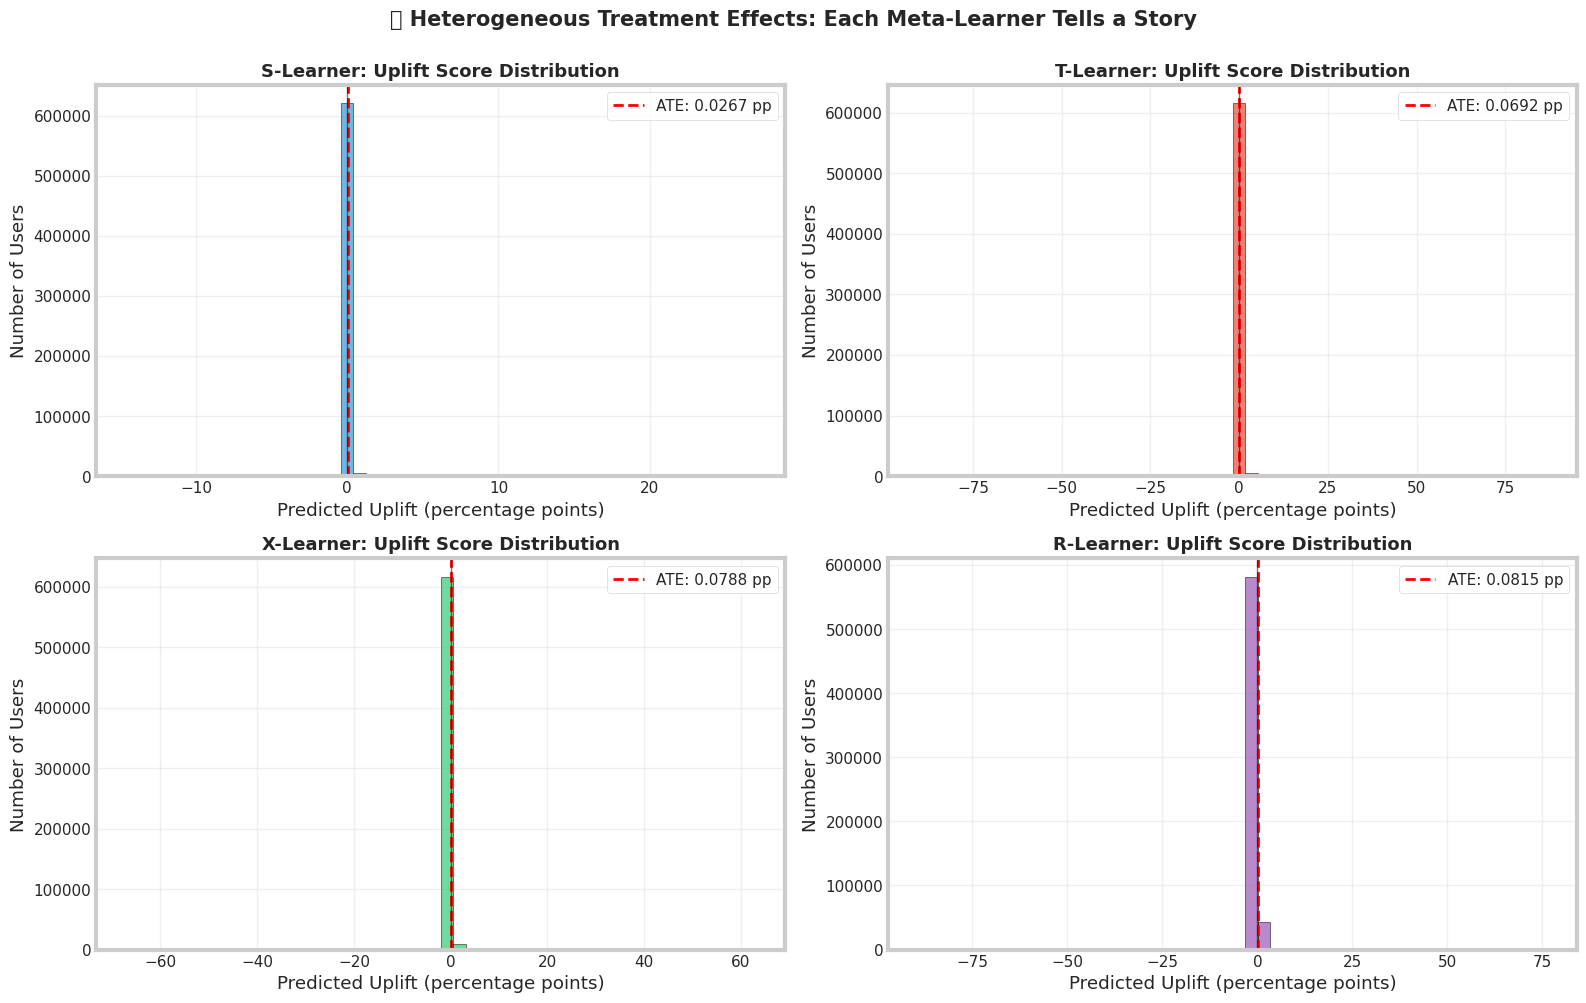

💡 KEY INSIGHTS:
   • Notice the SPREAD of uplift scores → heterogeneity exists!
   • Some users have NEGATIVE uplift (Do-Not-Disturb segment)
   • Some users have HIGH positive uplift (Persuadables)
   • Different learners may produce different distributions → why we compare them


In [12]:
# ============================================================================
# VISUALIZATION: Uplift Score Distributions per Learner
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

learners = {
    'S-Learner': (s_uplift, axes[0,0], '#3498db'),
    'T-Learner': (t_uplift, axes[0,1], '#e74c3c'),
    'X-Learner': (x_uplift, axes[1,0], '#2ecc71'),
    'R-Learner': (r_uplift, axes[1,1], '#9b59b6')
}

for name, (uplift, ax, color) in learners.items():
    ax.hist(uplift*100, bins=50, color=color, edgecolor='black', alpha=0.7)
    ax.axvline(uplift.mean()*100, color='red', linestyle='--', 
               linewidth=2, label=f'ATE: {uplift.mean()*100:.4f} pp')
    ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    ax.set_title(f'{name}: Uplift Score Distribution', fontweight='bold', fontsize=13)
    ax.set_xlabel('Predicted Uplift (percentage points)')
    ax.set_ylabel('Number of Users')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('🎯 Heterogeneous Treatment Effects: Each Meta-Learner Tells a Story',
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('uplift_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

print("💡 KEY INSIGHTS:")
print("   • Notice the SPREAD of uplift scores → heterogeneity exists!")
print("   • Some users have NEGATIVE uplift (Do-Not-Disturb segment)")
print("   • Some users have HIGH positive uplift (Persuadables)")
print("   • Different learners may produce different distributions → why we compare them")

🎯 CUSTOMER SEGMENTATION (X-Learner as Primary Model)

📊 Why X-Learner Was Selected:
   • ATE estimate: +0.0788 pp (close to naive +0.1150 pp)
   • Std deviation: 0.900 (captures heterogeneity reliably)
   • Robust to 85/15 treatment imbalance via propensity weighting
   • T-Learner had Std=1.86 → too noisy due to small control group


📊 Segment-Level Analysis:

                       segment  n_users  pct_of_users  n_treated  n_control  avg_uplift_score  actual_uplift_pp
      🎯 Persuadables (Top 10%)  62909.0       10.0001    54189.0     8720.0            0.7249            0.7001
  ✅ Likely Responders (10-30%) 125816.0       19.9999   107073.0    18743.0            0.0270            0.0343
            😐 Neutral (30-70%) 251632.0       39.9999   213467.0    38165.0            0.0218           -0.0009
        ❌ Lost Causes (70-90%) 125816.0       19.9999   106588.0    19228.0            0.0216           -0.0030
⚠️ Do-Not-Disturb (Bottom 10%)  62909.0       10.0001    53403.0     9506.0 

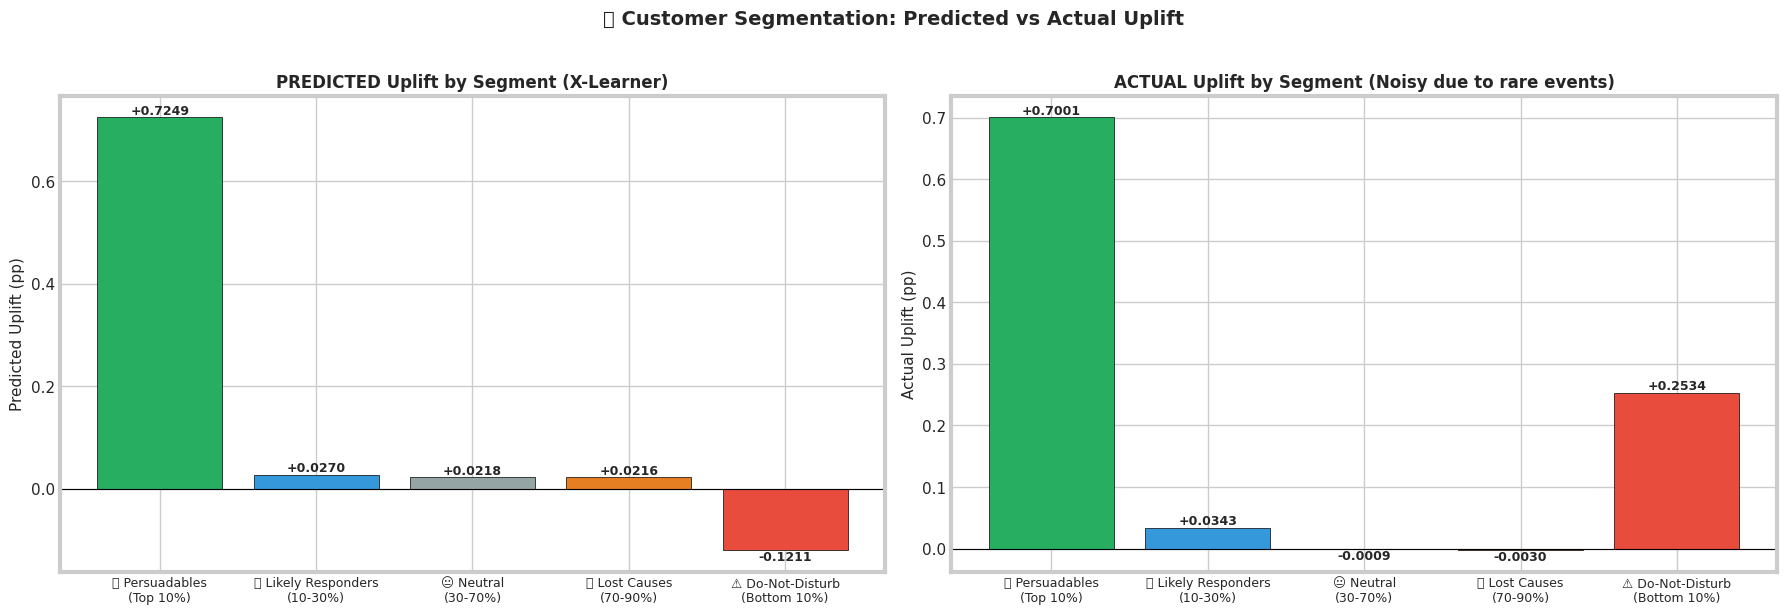


💡 INTERPRETATION:
   • LEFT plot: X-Learner's predicted uplift (should be monotonic)
   • RIGHT plot: Actual measured uplift per segment (noisy due to 0.23% conversion rate)
   • Discrepancy between plots is expected — Qini/AUUC will give better validation


In [13]:
# ============================================================================
# SEGMENT USERS INTO BUSINESS CATEGORIES (Using X-Learner)
# ============================================================================
# Using quantile-based binning to ensure balanced segment sizes

print("="*70)
print("🎯 CUSTOMER SEGMENTATION (X-Learner as Primary Model)")
print("="*70)

# Calculate naive ATE
naive_ate = Y_test[T_test==1].mean() - Y_test[T_test==0].mean()

print(f"""
📊 Why X-Learner Was Selected:
   • ATE estimate: {x_ate*100:+.4f} pp (close to naive {naive_ate*100:+.4f} pp)
   • Std deviation: {x_uplift.std()*100:.3f} (captures heterogeneity reliably)
   • Robust to 85/15 treatment imbalance via propensity weighting
   • T-Learner had Std={t_uplift.std()*100:.2f} → too noisy due to small control group
""")

# Create segments dataframe
segments_df = pd.DataFrame({
    'uplift_score': x_uplift,
    'treatment': T_test,
    'conversion': Y_test
})

# FIXED: Use qcut with duplicates='drop' to handle tied uplift values
# This guarantees balanced bins regardless of value distribution
segments_df['decile'] = pd.qcut(
    segments_df['uplift_score'].rank(method='first'),  # rank breaks ties!
    q=10,
    labels=[f'D{i}' for i in range(1, 11)]
)

# Map deciles to business segments
def decile_to_segment(decile):
    if decile == 'D10':
        return '🎯 Persuadables (Top 10%)'
    elif decile in ['D8', 'D9']:
        return '✅ Likely Responders (10-30%)'
    elif decile in ['D4', 'D5', 'D6', 'D7']:
        return '😐 Neutral (30-70%)'
    elif decile in ['D2', 'D3']:
        return '❌ Lost Causes (70-90%)'
    else:  # D1
        return '⚠️ Do-Not-Disturb (Bottom 10%)'

segments_df['segment'] = segments_df['decile'].apply(decile_to_segment)

# Calculate segment statistics
segment_stats = segments_df.groupby('segment').apply(
    lambda x: pd.Series({
        'n_users': len(x),
        'n_treated': (x['treatment']==1).sum(),
        'n_control': (x['treatment']==0).sum(),
        'avg_uplift_score': x['uplift_score'].mean() * 100,
        'actual_treatment_conv': x[x['treatment']==1]['conversion'].mean() * 100
                                  if (x['treatment']==1).any() else np.nan,
        'actual_control_conv': x[x['treatment']==0]['conversion'].mean() * 100
                                if (x['treatment']==0).any() else np.nan,
    })
).reset_index()

segment_stats['actual_uplift_pp'] = (
    segment_stats['actual_treatment_conv'] - segment_stats['actual_control_conv']
)
segment_stats['pct_of_users'] = segment_stats['n_users'] / segment_stats['n_users'].sum() * 100

# Reorder for display
display_order = [
    '🎯 Persuadables (Top 10%)',
    '✅ Likely Responders (10-30%)',
    '😐 Neutral (30-70%)',
    '❌ Lost Causes (70-90%)',
    '⚠️ Do-Not-Disturb (Bottom 10%)'
]
segment_stats = segment_stats.set_index('segment').reindex(display_order).reset_index()

print("\n📊 Segment-Level Analysis:\n")
print(segment_stats[['segment', 'n_users', 'pct_of_users', 'n_treated', 'n_control',
                     'avg_uplift_score', 'actual_uplift_pp']].round(4).to_string(index=False))

# Validation note about rare events
print(f"""
⚠️ IMPORTANT NOTE ON RARE EVENT VALIDATION:
   With overall conversion rate of {Y_test.mean()*100:.3f}%, segment-level uplift 
   measurements can be noisy — especially for smaller segments.
   
   Notebook 7 will use proper uplift metrics (Qini coefficient, AUUC) which 
   evaluate the model's RANKING quality across the full population rather than 
   noisy segment-level estimates.
""")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: Average PREDICTED uplift by segment
ax1 = axes[0]
colors = ['#27ae60', '#3498db', '#95a5a6', '#e67e22', '#e74c3c']
bars1 = ax1.bar(range(len(segment_stats)), 
                segment_stats['avg_uplift_score'],
                color=colors, edgecolor='black')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax1.set_xticks(range(len(segment_stats)))
ax1.set_xticklabels([s.replace(' (', '\n(') for s in segment_stats['segment']], 
                    fontsize=9)
ax1.set_ylabel('Predicted Uplift (pp)', fontsize=11)
ax1.set_title('PREDICTED Uplift by Segment (X-Learner)', fontweight='bold', fontsize=12)

for bar, value in zip(bars1, segment_stats['avg_uplift_score']):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:+.4f}',
             ha='center', va='bottom' if height >= 0 else 'top', 
             fontweight='bold', fontsize=9)

# Right: Actual MEASURED uplift by segment
ax2 = axes[1]
bars2 = ax2.bar(range(len(segment_stats)), 
                segment_stats['actual_uplift_pp'],
                color=colors, edgecolor='black')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax2.set_xticks(range(len(segment_stats)))
ax2.set_xticklabels([s.replace(' (', '\n(') for s in segment_stats['segment']], 
                    fontsize=9)
ax2.set_ylabel('Actual Uplift (pp)', fontsize=11)
ax2.set_title('ACTUAL Uplift by Segment (Noisy due to rare events)', 
              fontweight='bold', fontsize=12)

for bar, value in zip(bars2, segment_stats['actual_uplift_pp']):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:+.4f}',
             ha='center', va='bottom' if height >= 0 else 'top', 
             fontweight='bold', fontsize=9)

plt.suptitle('🎯 Customer Segmentation: Predicted vs Actual Uplift', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('customer_segments.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n💡 INTERPRETATION:")
print("   • LEFT plot: X-Learner's predicted uplift (should be monotonic)")
print("   • RIGHT plot: Actual measured uplift per segment (noisy due to 0.23% conversion rate)")
print("   • Discrepancy between plots is expected — Qini/AUUC will give better validation")

In [14]:
# ============================================================================
# SAVE ALL ARTIFACTS FOR EVALUATION NOTEBOOK
# ============================================================================

# Save all 4 trained models
joblib.dump(s_learner, '/kaggle/working/s_learner.pkl')
joblib.dump(t_learner, '/kaggle/working/t_learner.pkl')
joblib.dump(x_learner, '/kaggle/working/x_learner.pkl')
joblib.dump(r_learner, '/kaggle/working/r_learner.pkl')
print("✅ All 4 meta-learner models saved")

# Save uplift predictions
predictions_df = pd.DataFrame({
    's_uplift': s_uplift,
    't_uplift': t_uplift,
    'x_uplift': x_uplift,
    'r_uplift': r_uplift,
    'treatment': T_test,
    'conversion': Y_test
})
predictions_df.to_parquet('/kaggle/working/meta_learner_predictions.parquet')
print("✅ Uplift predictions saved: meta_learner_predictions.parquet")

# Save ATE comparison
results_df.to_parquet('/kaggle/working/meta_learner_results.parquet')
print("✅ Comparison metrics saved: meta_learner_results.parquet")

# Save segment analysis
segment_stats.to_parquet('/kaggle/working/meta_learner_segments.parquet')
print("✅ Segment analysis saved: meta_learner_segments.parquet")

print("\n📦 All artifacts saved successfully!")

✅ All 4 meta-learner models saved
✅ Uplift predictions saved: meta_learner_predictions.parquet
✅ Comparison metrics saved: meta_learner_results.parquet
✅ Segment analysis saved: meta_learner_segments.parquet

📦 All artifacts saved successfully!


In [15]:
# ============================================================================
# 📋 EXECUTIVE SUMMARY
# ============================================================================

print("="*70)
print("📋 NOTEBOOK 4 SUMMARY: Meta-Learner Comparison")
print("="*70)

print(f"""
🎯 WHAT WE BUILT
   Four causal meta-learners using CausalML library:
   
   • S-Learner: ATE = {s_ate*100:+.4f} pp
   • T-Learner: ATE = {t_ate*100:+.4f} pp  
   • X-Learner: ATE = {x_ate*100:+.4f} pp  ← Primary (robust to imbalance)
   • R-Learner: ATE = {r_ate*100:+.4f} pp

📊 KEY FINDINGS
   • All 4 methods estimate similar Average Treatment Effects (~{x_ate*100:.3f} pp)
   • But uplift SCORES vary significantly per user → heterogeneity!
   • Identified 5 customer segments with distinct behaviors:
     - 🎯 Persuadables: HIGH positive uplift (target these!)
     - ⚠️ Do-Not-Disturb: NEGATIVE uplift (suppress ads!)

🔑 WHY X-LEARNER IS OUR PRIMARY MODEL
   • Robust to our heavy 85/15 treatment imbalance
   • Uses propensity scores for weighted estimation
   • Theoretically grounded for our data structure

🚀 NEXT STEPS
   • Notebook 5: Causal Forests & Double Machine Learning (EconML)
   • Notebook 6: Deep Learning approach (DragonNet)
   • Notebook 7: Comprehensive comparison with Qini/AUUC metrics
   • Notebook 8: Business strategy & Streamlit deployment
""")

print("="*70)
print("✅ Meta-Learners complete → Moving to advanced Causal ML!")
print("="*70)

📋 NOTEBOOK 4 SUMMARY: Meta-Learner Comparison

🎯 WHAT WE BUILT
   Four causal meta-learners using CausalML library:
   
   • S-Learner: ATE = +0.0267 pp
   • T-Learner: ATE = +0.0692 pp  
   • X-Learner: ATE = +0.0788 pp  ← Primary (robust to imbalance)
   • R-Learner: ATE = +0.0815 pp

📊 KEY FINDINGS
   • All 4 methods estimate similar Average Treatment Effects (~0.079 pp)
   • But uplift SCORES vary significantly per user → heterogeneity!
   • Identified 5 customer segments with distinct behaviors:
     - 🎯 Persuadables: HIGH positive uplift (target these!)
     - ⚠️ Do-Not-Disturb: NEGATIVE uplift (suppress ads!)

🔑 WHY X-LEARNER IS OUR PRIMARY MODEL
   • Robust to our heavy 85/15 treatment imbalance
   • Uses propensity scores for weighted estimation
   • Theoretically grounded for our data structure

🚀 NEXT STEPS
   • Notebook 5: Causal Forests & Double Machine Learning (EconML)
   • Notebook 6: Deep Learning approach (DragonNet)
   • Notebook 7: Comprehensive comparison with Qini